In [ ]:
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession

config = ConfigProto()
config.gpu_options.per_process_gpu_memory_fraction = 0.5
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)

In [ ]:
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.inception_v3 import InceptionV3
from keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.models import Sequential
import numpy as np
from glob import glob

In [ ]:
IMAGE_SIZE = [256, 256]

train_path = '/content/drive/MyDrive/bb/CSE299/Datasets/train'
valid_path = '/content/drive/MyDrive/bb/CSE299/Datasets/test'

In [ ]:
inception = InceptionV3(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [ ]:
for layer in inception.layers:
    layer.trainable = False

In [ ]:
folders = glob('/content/drive/MyDrive/bb/CSE299/Datasets/train*')

In [ ]:
x = Flatten()(inception.output)

In [ ]:
prediction = Dense(len(folders), activation='softmax')(x)

model = Model(inputs=inception.input, outputs=prediction)

In [ ]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 127, 127, 32)         864       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 127, 127, 32)         96        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 127, 127, 32)         0         ['batch_normalization[0][0

In [ ]:
model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

In [ ]:
training_set = train_datagen.flow_from_directory('/content/drive/MyDrive/bb/CSE299/Datasets/train',
                                                 target_size = (256, 256),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

Found 10099 images belonging to 8 classes.


In [ ]:
test_set = test_datagen.flow_from_directory('/content/drive/MyDrive/bb/CSE299/Datasets/test',
                                            target_size = (256, 256),
                                            batch_size = 32,
                                            class_mode = 'categorical')

Found 10099 images belonging to 8 classes.


In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
r = model.fit(
    training_set,
  validation_data=test_set,
  epochs=10,
  steps_per_epoch=len(training_set),
  validation_steps=len(test_set)

)

Epoch 1/10
316/316 [==============================] - 2160s 7s/step - loss: 0.7020 - accuracy: 0.1250 - val_loss: 0.7070 - val_accuracy: 0.1250
Epoch 2/10
316/316 [==============================] - 2151s 7s/step - loss: 0.6984 - accuracy: 0.1250 - val_loss: 0.7173 - val_accuracy: 0.1250
Epoch 3/10
316/316 [==============================] - 2213s 7s/step - loss: 0.6456 - accuracy: 0.1250 - val_loss: 0.5514 - val_accuracy: 0.1250
Epoch 4/10
316/316 [==============================] - 2214s 7s/step - loss: 0.7183 - accuracy: 0.1250 - val_loss: 0.7588 - val_accuracy: 0.1250
Epoch 5/10
316/316 [==============================] - 2160s 7s/step - loss: 0.7118 - accuracy: 0.1250 - val_loss: 0.6757 - val_accuracy: 0.1250
Epoch 6/10
316/316 [==============================] - 2151s 7s/step - loss: 0.7189 - accuracy: 0.1250 - val_loss: 0.6337 - val_accuracy: 0.1250
Epoch 7/10
316/316 [==============================] - 2212s 7s/step - loss: 0.8489 - accuracy: 0.1250 - val_loss: 0.6111 - val_accuracy:

In [ ]:
import matplotlib.pyplot as plt

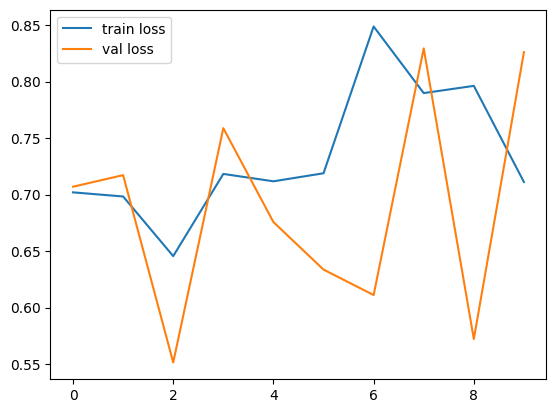

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')



In [ ]:
from tensorflow.keras.models import load_model

model.save('model_inception.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
y_pred = model.predict(test_set)

316/316 [==============================] - 1062s 3s/step
